In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Step 2: Create synthetic sales data


np.random.seed(42)

days = pd.date_range(
    start="2025-01-01",
    periods=913
)

In [ ]:
# Step 3: Generate cyclic sales pattern


sales = (
        200
        + 50*np.sin(
            2*np.pi*np.arange(913)/30
          )
        + np.random.normal(
            0,
            10,
            913
          )
)

In [ ]:
# Step 4: Inject anomalies manually


sales[80] = 400
sales[160] = 50
sales[250] = 380
sales[500]= 500
sales[578]=400
sales[798]=560

In [ ]:
# Step 5: Create dataframe


df = pd.DataFrame({
    'Date':days,
    'Sales':sales
})

df.head()

,Date,Sales
0,2025-01-01,201.920491
1,2025-01-02,207.304420
2,2025-01-03,221.672241
3,2025-01-04,227.864564
4,2025-01-05,244.238328


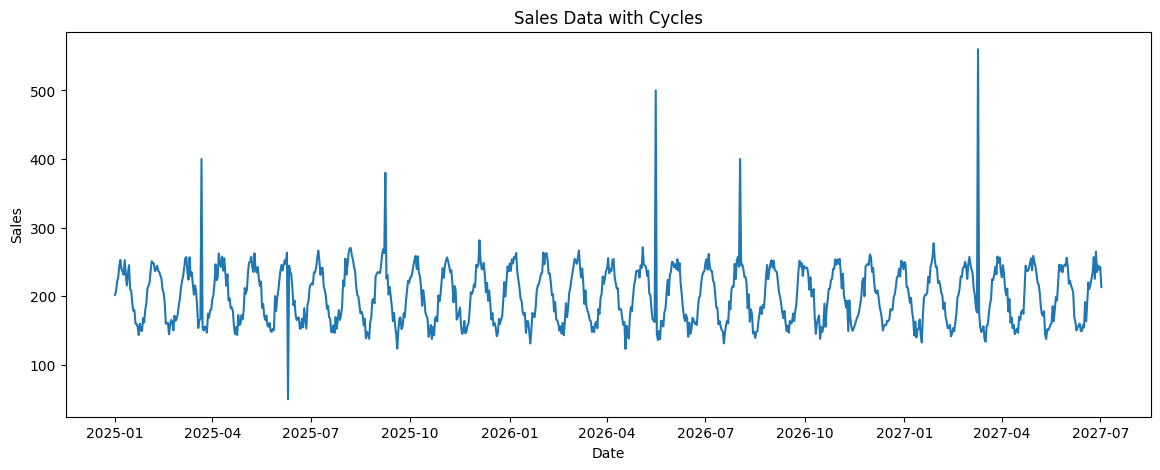

In [ ]:
# Step 6: Visualize sales


plt.figure(figsize=(14,5))

plt.plot(
    df['Date'],
    df['Sales']
)

plt.title(
    "Sales Data with Cycles"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [ ]:
# Step 7: Calculate rolling average


df['RollingMean']=(
    df['Sales']
    .rolling(window=30)
    .mean()
)

In [ ]:

# Step 8: Rolling standard deviation

df['RollingStd']=(
    df['Sales']
    .rolling(window=30)
    .std()
)

In [ ]:
# Step 9: Compute Z-score


df['Zscore']=(
    abs(
        (
        df['Sales']
        -
        df['RollingMean']
        )
        /
        df['RollingStd']
    )
)

In [ ]:
# Step 10: Detect anomalies

threshold=2

df['Anomaly']=(
    df['Zscore']
    >
    threshold
)

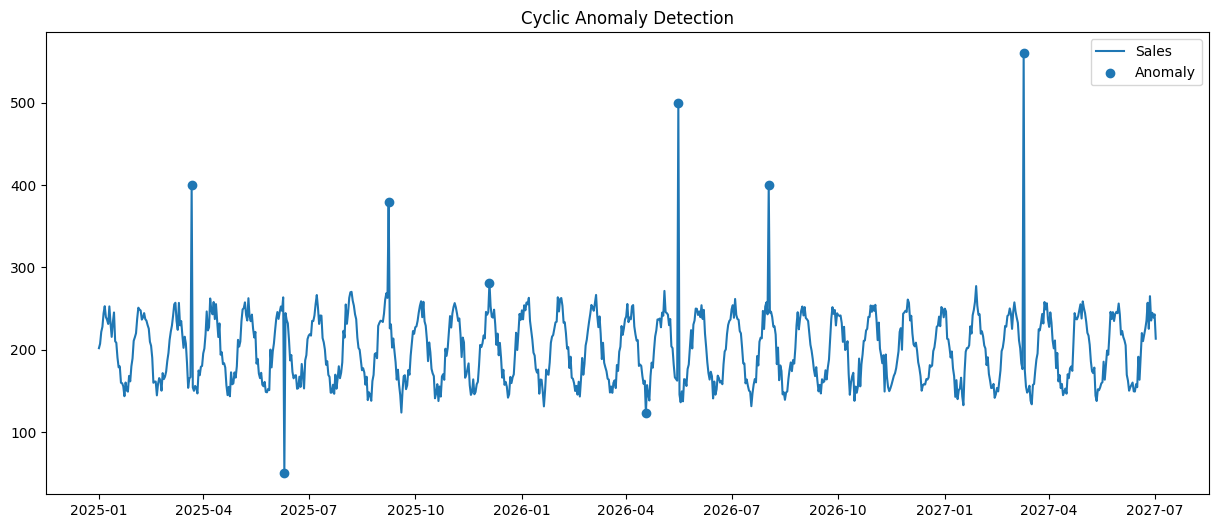

In [ ]:
# Step 11: Plot anomalies


plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Sales'],
    label="Sales"
)

plt.scatter(
    df[df['Anomaly']]['Date'],
    df[df['Anomaly']]['Sales'],
    label='Anomaly'
)

plt.legend()

plt.title(
    "Cyclic Anomaly Detection"
)

plt.show()


In [ ]:
# Step 12: Show detected anomalies


print(
    df[
       df['Anomaly']
    ][
      ['Date',
       'Sales']
    ]
)


          Date       Sales
80  2025-03-22  400.000000
160 2025-06-10   50.000000
250 2025-09-08  380.000000
337 2025-12-04  281.657170
472 2026-04-18  123.241582
500 2026-05-16  500.000000
578 2026-08-02  400.000000
798 2027-03-10  560.000000
